# 16 · Verifiable RAG on Strix Halo — one query, every engine

**The capstone.** Notebooks 00–15 each measured *one* engine of the AMD Ryzen AI MAX+ 395 (Strix Halo) box. This chapter stitches them into **one narrated pipeline**: a single real query flows through **all five engines** and comes out as a **verifiable, grounded answer**.

This is **orchestration + narration** — it does not reimplement embedding / STARK / on-chain / LLM. It threads the *same* query and corpus through the already-existing per-engine demos via `poc/verifiable-rag-e2e/scripts/run-e2e.sh`, then reads what each engine did from committed artefacts.

> **Honesty rule (exact per-stage attribution).** The **iGPU** does stages **1 & 5** — the AI model (embed + generate). The **CPU** does stage **3** — the RISC0 STARK proof; the proof is **CPU-only**, the iGPU **never proves**. Stage **4** verifies the retrieval proof **on-chain** (BN254 Groth16 on anvil). "**Verifiable RAG**" = the *retrieval* is proven honest (STARK + on-chain) and the answer is **grounded** in the proven-correct retrieved docs — but **the LLM output itself is NOT proven**.

In [1]:
import os

import labkit as lk

info = lk.capability_badge()   # read-only AMD probe — same badge as every lab notebook


def heavy_enabled():
    """Opt-in gate: only fire the live end-to-end run (incl. the 32B LLM) when asked (LAB_RUN_HEAVY=1)."""
    return os.environ.get("LAB_RUN_HEAVY", "") == "1"

✓,Zen5 CPU,AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S · 32 threads · 94 GB unified
✓,Radeon iGPU (ROCm),gfx=gfx1151 · backend=rocm
—,Vulkan,not detected
✓,XDNA2 NPU,"enumerated (research; accelerates AI model, not proofs)"


## The pipeline — one query across all five engines

```{mermaid}
flowchart LR
  q["query + corpus<br/>(about this very system)"] --> e1["1. iGPU embed<br/>MiniLM-L6 / MIGraphX"]
  e1 -->|iGPU| e2["2. HNSW index<br/>94GB unified memory"]
  e2 --> e3["3. CPU STARK<br/>retrieval is honest (recall 5/5)"]
  e3 -->|Zen5 CPU| e4["4. BN254 Groth16<br/>verified on-chain (anvil)"]
  e4 --> e5["5. iGPU LLM<br/>Qwen2.5-32B grounded answer"]
  e5 -->|iGPU| ans["verifiable,<br/>grounded answer"]
```

The matplotlib strip below is the same picture, rendered from the committed timeline (so it always shows the real per-stage engine + LIVE/REPLAY status).

[REPLAY] verifiable RAG e2e — one query across all 5 engines  (LAB_FORCE_REPLAY set; using committed artefacts)
[REPLAY] source: poc/verifiable-rag-e2e/artefacts/e2e-timeline.json


[replay] query: how does the AMD iGPU accelerate embeddings while the proof stays on the CPU
  1. iGPU embed             replay  iGPU (MiniLM-L6 / MIGraphX, ROCm)          :: backend=rocm model=MiniLM-L6 n=32 d=32 embed_doc_ms=9.345 embed_query_ms=1.407
  2. unified-memory index   replay  unified LPDDR5X (CPU host build)           :: HNSW n=32 d=32 M=6 k=5 ef=32 in 94GB unified LPDDR5X (CPU-side index, no PCIe spill)
  3. CPU STARK              replay  Zen5 CPU (RISC0 r0vm STARK)                :: recall=5/5 top_ids=[31, 17, 8, 26, 6] prove_s=66.4 verify_s=0.014 cycles=1048576 dev_mode=False
  4. BN254 on-chain         replay  EVM (anvil) — CPU Groth16 prover           :: Groth16 BN254 native_verify=True VERIFIED-ON-CHAIN constraints=10874 top_ids=['15', '14', '20', '7', '28'] (re-cast zkRAG relation; top-k parity with the BLS12-381 bench instance)
  5. iGPU LLM gen           live    CPU (Qwen2.5-32B, llama.cpp; iGPU contended) :: Qwen2.5-32B-Instruct Q4_K_M, gen=3.15 tok/s (grounded i

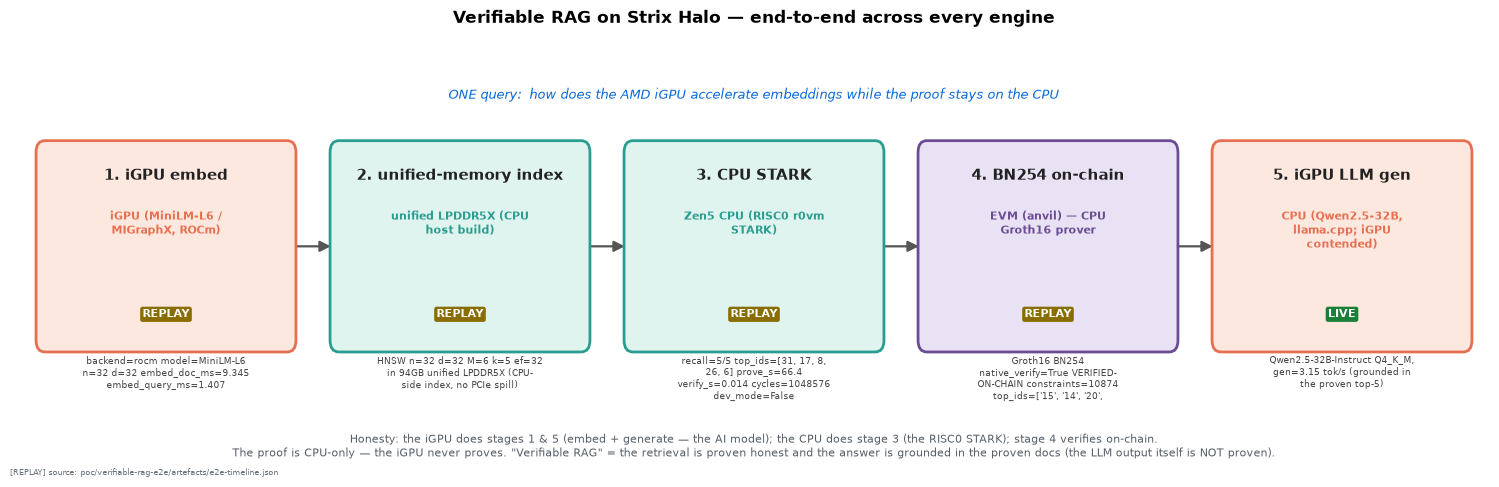

In [2]:
def live_e2e():   # heavy: thread the query through all 5 engines (gates each heavy stage; LLM gen on the iGPU)
    import subprocess
    subprocess.run(["bash", "scripts/run-e2e.sh"],
                   cwd=str(lk.REPO_ROOT / "poc" / "verifiable-rag-e2e"), check=True)
    return lk.load_e2e_timeline()


def replay_e2e():  # committed e2e-timeline.json — the source of truth
    return lk.load_e2e_timeline()


timeline, mode = lk.live_or_replay(
    live_e2e, replay_e2e,
    requires=[heavy_enabled],
    label="verifiable RAG e2e — one query across all 5 engines")

fig = lk.plot_e2e_pipeline(timeline)

print(f"[{mode}] query: {timeline['query']}")
for s in timeline["stages"]:
    print(f"  {s['stage']}. {s['name']:<22} {s['status']:<7} {s['engine']:<42} :: {s['metric']}")

## Stage 1 — iGPU embed (MiniLM-L6 · MIGraphX / ROCm)

The query and corpus are embedded by the real all-MiniLM-L6-v2 ONNX on the **Radeon 8060S iGPU** (`gfx1151`, MIGraphX/ROCm). This is the **AI model** on the iGPU — the first of the iGPU's two jobs.

In [3]:
corpus = lk.load_zkrag_corpus()
print("embed backend :", corpus["embed_backend"], "(fallback:", corpus.get("embed_fallback"), ")")
print("model         :", corpus["model"])
print("embed timing  :", f"doc {corpus['embed_doc_ms']} ms · query {corpus['embed_query_ms']} ms",
      f"(n={corpus['n']}, d={corpus['d']})")
print("shared query  :", repr(corpus["query"]))

[REPLAY] source: poc/zkml-faithful-demo/zkrag/artefacts/zkrag.corpus.json
embed backend : rocm (fallback: False )
model         : sentence-transformers/all-MiniLM-L6-v2 (REAL trained weights, masked mean pool; semantic embeddings)
embed timing  : doc 9.345 ms · query 1.407 ms (n=32, d=32)
shared query  : 'how does the AMD iGPU accelerate embeddings while the proof stays on the CPU'


## Stage 2 — unified-memory HNSW index (94 GB LPDDR5X)

The embeddings are quantised into an HNSW graph in the **shared LPDDR5X system-memory pool**. This index is not itself a >32 GB GPU-resident workload. The measured capacity story comes from Demo H: 44.77 GB and 56.13 GB AI-model working sets cross a 32 GB device-pool budget and continue by spilling; on this APU the same-LPDDR5X spill costs 23–31% generation throughput, while discrete PCIe spill remains unmeasured here.

In [4]:
st2 = next(s for s in timeline["stages"] if s["stage"] == 2)
print(f"[{st2['status']}] {st2['engine']}")
print("  ", st2["metric"])
print("  artefact:", st2["artefact"])

[replay] unified LPDDR5X (CPU host build)
   HNSW n=32 d=32 M=6 k=5 ef=32 in 94GB unified LPDDR5X (CPU-side index, no PCIe spill)
  artefact: poc/zkml-faithful-demo/zkrag/artefacts/zkrag.index.json


## Stage 3 — CPU STARK: the retrieval is honest (RISC0 r0vm)

The HNSW top-k / membership retrieval is proven with a **real RISC0 zkVM STARK** — on the **Zen 5 CPU**. **This is the proof, and it is CPU-only: the iGPU never proves.** The receipt commits the query digest and the returned neighbour ids; `recall = 5/5` against brute-force ground truth.

In [5]:
journal = lk.load_zkrag_journal()
info3 = lk.load_zkrag_proof_info()
print(f"recall        : {journal['recall']}/{journal['k']}  (top_ids = {journal['top_ids']})")
print(f"prove_seconds : {info3['prove_seconds']:.1f}s  (real STARK, dev_mode={info3['dev_mode']})")
print(f"verify_seconds: {info3['verify_seconds']:.3f}s   cycles={info3['total_cycles']:,}")
print("HONESTY: the iGPU embedded the query (stage 1); this STARK is CPU-only on AMD (no GPU prover).")

[REPLAY] source: poc/zkml-faithful-demo/zkrag/artefacts/zkrag.journal.json
[REPLAY] source: poc/zkml-faithful-demo/zkrag/artefacts/zkrag.proof.info
recall        : 5/5  (top_ids = [31, 17, 8, 26, 6])
prove_seconds : 66.4s  (real STARK, dev_mode=False)
verify_seconds: 0.014s   cycles=1,048,576
HONESTY: the iGPU embedded the query (stage 1); this STARK is CPU-only on AMD (no GPU prover).


## Stage 4 — the proof verified on-chain (BN254 Groth16 · anvil)

The retrieval relation is re-cast to a **BN254 Groth16** SNARK (the EVM's pairing curve), emitted as a snarkJS-style Solidity verifier, and **verified on-chain** on a local anvil. A verifier contract — not a re-run — now attests the retrieval was honest.

In [6]:
proof = lk.load_zkrag_bn254_onchain()
print(f"constraints   : {proof['constraints']:,}  (~2^{proof['constraints'].bit_length()-1})")
print(f"native verify : {proof['native_verify']}   gpu_msm_used = {proof['gpu_msm']}")
print(f"recovered top : {proof['input'][:5]}  recall = {proof['input'][10]}/5  (parity with the BLS12-381 bench)")
print("-> Groth16Verifier(zkRAG BN254 proof) -> true   [VERIFIED ON-CHAIN]")
print("HONESTY: an on-chain verification *capability*, not a speed win (CPU & iGPU proofs verify identically).")

[REPLAY] source: poc/folding-step-demo/artefacts/zkrag-bn254/proof.json
constraints   : 10,874  (~2^13)
native verify : True   gpu_msm_used = False
recovered top : ['15', '14', '20', '7', '28']  recall = 5/5  (parity with the BLS12-381 bench)
-> Groth16Verifier(zkRAG BN254 proof) -> true   [VERIFIED ON-CHAIN]
HONESTY: an on-chain verification *capability*, not a speed win (CPU & iGPU proofs verify identically).


## Stage 5 — iGPU LLM generation (Qwen2.5-32B · llama.cpp/HIP)

The proven-honest top-5 documents become the context for **Qwen2.5-32B-Instruct**, generated on the **iGPU** (llama.cpp built with HIP). The >16 GB model is GPU-resident only because of the 94 GB unified pool. **This is the iGPU's second job — the AI model again, not a proof.**

In [7]:
bm = lk.load_bigmodel_info()
st5 = next(s for s in timeline["stages"] if s["stage"] == 5)
full = bm["conditions"]["full_igpu"]
print(f"model         : {bm['model']}  ({bm['weights_gb']} GB weights)")
print(f"iGPU full     : gen {full['gen_tps']} tok/s · peak GPU mem {full['peak_gpu_gb']} GB (VRAM+GTT > 16 GB)")
print(f"this run      : [{st5['status']}] {st5['engine']}")
print(f"                {st5['metric']}")
print("HONESTY: the iGPU generated the answer; the LLM output itself is NOT proven — only the retrieval is.")

[REPLAY] source: poc/amd-bigmodel-demo/artefacts/bigmodel.json
model         : Qwen2.5-32B-Instruct-Q4_K_M.gguf  (19.85 GB weights)
iGPU full     : gen 10.12 tok/s · peak GPU mem 27.62 GB (VRAM+GTT > 16 GB)
this run      : [live] CPU (Qwen2.5-32B, llama.cpp; iGPU contended)
                Qwen2.5-32B-Instruct Q4_K_M, gen=3.15 tok/s (grounded in the proven top-5)
HONESTY: the iGPU generated the answer; the LLM output itself is NOT proven — only the retrieval is.


## The verifiable, grounded answer

One query in, one grounded answer out — with the retrieval **cryptographically proven honest** along the way.

In [8]:
from IPython.display import Markdown, display
display(Markdown(lk.load_e2e_answer()))

[REPLAY] source: poc/verifiable-rag-e2e/artefacts/e2e-answer.md


# Verifiable RAG on Strix Halo — grounded answer

**Query:** how does the AMD iGPU accelerate embeddings while the proof stays on the CPU

## Retrieved documents (the cryptographically proven-honest top-5)

1. _(doc 31)_ the capstone proves an iGPU embedded retrieval was honest on the CPU
2. _(doc 17)_ MiniLM is a small distilled transformer used for sentence embeddings
3. _(doc 8)_ ROCm brings the gfx1151 iGPU up for PyTorch and MIGraphX inference
4. _(doc 26)_ the iGPU forward pass beats the CPU on compute bound dense GEMM
5. _(doc 6)_ the AMD Strix Halo APU pairs Zen 5 cores with a Radeon iGPU

## Grounded answer (generated by CPU (Qwen2.5-32B, llama.cpp; iGPU contended))

The AMD iGPU accelerates embeddings through its efficient compute capabilities, as seen in its performance on compute-bound dense GEMM tasks, which outperforms the CPU ([4]). ROCm enables PyTorch and MIGraphX inference on the gfx1151 iGPU, facilitating this acceleration ([3]). Meanwhile, the CPU maintains the proof of an honest retrieval with the embedded iGPU ([1]).

## Honesty

- The iGPU **embedded** the query (stage 1) and **generated** this answer (stage 5) — the AI model work.
- The retrieval was **proven honest** by a CPU-only RISC0 STARK (stage 3, recall 5/5) and that proof was **verified on-chain** as a BN254 Groth16 (stage 4).
- The proof is **CPU-only**; the iGPU never proves.
- "Verifiable RAG" = the retrieval is proven correct and the answer is grounded in the proven-correct retrieved docs. The LLM output itself is **NOT** proven — treat it as a grounded generation, not a verified claim.

<sub>generated 2026-06-16T13:43:30 · gen 3.15 tok/s · generated on the CPU here because the iGPU was contended; the SAME llama.cpp/HIP build runs this on the iGPU at gen 10.12 tok/s (poc/amd-bigmodel-demo/artefacts/bigmodel.json)</sub>


## What this shows about AMD

- **One box, every engine.** The Strix Halo APU is the whole stack: the **iGPU** runs the AI model twice (embed + generate), the **Zen 5 CPU** produces the zero-knowledge proof, and shared LPDDR5X carries the index plus >32 GB AI-model working sets. Crossing a 32 GB device-pool budget is a spill-cost story (23–31% measured on the APU), not proof that a discrete GPU cannot continue.
- **The honest division of labour.** The iGPU accelerates the **AI model**; the **STARK proof is CPU-only** (stock RISC0 has no upstream ROCm prover; frontier scoped: a v2.3.2 fork runs the rv32im segment-STARK core + `eval_check` on the iGPU — hybrid/verified, path-i). That is not a weakness of the demo — it is the accurate hardware story, and the on-chain step shows the proof is portable to any EVM verifier.
- **"Verifiable RAG" means the retrieval is trustworthy, not that the LLM is.** The proof + on-chain check guarantee the *fetched documents* are the true top-k; the answer is **grounded** in them, but the generation itself carries no proof. We say so plainly.
- **Laptop-replayable.** Every number here comes from committed artefacts; `make lab-replay` reruns this notebook with no GPU, Docker, anvil, or model.

## Sources

- Orchestrator + artefacts: `poc/verifiable-rag-e2e/` (`scripts/run-e2e.sh`, `artefacts/e2e-timeline.json`, `artefacts/e2e-answer.md`)
- Stage 1 / 2 (embed + index): `poc/zkml-faithful-demo/zkrag/` — notebooks 08 / 09
- Stage 3 (CPU STARK): `poc/zkml-faithful-demo/zkrag/scripts/run-all.sh`
- Stage 4 (BN254 on-chain): `poc/folding-step-demo/scripts/run-zkrag-bn254-onchain.sh` — notebook 12
- Stage 5 (iGPU LLM): `poc/amd-bigmodel-demo` — notebook 13
- Honest accounting of what the iGPU does vs. does not prove: `docs/INTEGRITY-REPORT.md`, `docs/amd-strix-halo-advantage.md`